<a href="https://colab.research.google.com/github/debayanroy7/AIML-with-Cybersecurity-Internship/blob/main/Deep_Learning_Cyber_Threat_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Deep Learning Cyber Threat Detector**

Dataset Creation

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

rows = 20000

df = pd.DataFrame({

    "Login_Hour": np.random.randint(0,24,rows),

    "Failed_Logins": np.random.randint(0,15,rows),

    "Data_Transfer_MB": np.random.randint(10,5000,rows),

    "Suspicious_URLs": np.random.randint(0,20,rows),

    "Unknown_Device": np.random.randint(0,2,rows),

    "Malware_Score": np.random.randint(0,100,rows),

    "Firewall_Alerts": np.random.randint(0,15,rows),

    "External_Connections": np.random.randint(0,50,rows),

    "Privilege_Escalation": np.random.randint(0,2,rows)

})

In [ ]:
df.head(10)

,Login_Hour,Failed_Logins,Data_Transfer_MB,Suspicious_URLs,Unknown_Device,Malware_Score,Firewall_Alerts,External_Connections,Privilege_Escalation
0,6,8,4478,7,1,40,0,47,1
1,19,8,1457,16,0,22,1,3,0
2,14,7,524,0,0,49,7,41,0
3,10,11,4469,2,0,15,3,31,1
4,7,9,1923,16,0,91,7,14,1
5,20,7,1961,19,1,75,14,30,1
6,6,2,783,2,1,71,13,29,0
7,18,12,338,6,0,29,5,13,0
8,22,2,803,10,1,59,0,13,0
9,10,1,971,14,0,60,5,46,0


Create Threat Labels

In [ ]:
df["Threat"] = (
    (df["Failed_Logins"] > 7) |
    (df["Suspicious_URLs"] > 10) |
    (df["Unknown_Device"] == 1) |
    (df["Malware_Score"] > 60) |
    (df["Firewall_Alerts"] > 5) |
    (df["Privilege_Escalation"] == 1)
).astype(int)

df.head()

,Login_Hour,Failed_Logins,Data_Transfer_MB,Suspicious_URLs,Unknown_Device,Malware_Score,Firewall_Alerts,External_Connections,Privilege_Escalation,Threat
0,6,8,4478,7,1,40,0,47,1,1
1,19,8,1457,16,0,22,1,3,0,1
2,14,7,524,0,0,49,7,41,0,1
3,10,11,4469,2,0,15,3,31,1,1
4,7,9,1923,16,0,91,7,14,1,1


Exploratory Data Analysis

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Login_Hour            20000 non-null  int64
 1   Failed_Logins         20000 non-null  int64
 2   Data_Transfer_MB      20000 non-null  int64
 3   Suspicious_URLs       20000 non-null  int64
 4   Unknown_Device        20000 non-null  int64
 5   Malware_Score         20000 non-null  int64
 6   Firewall_Alerts       20000 non-null  int64
 7   External_Connections  20000 non-null  int64
 8   Privilege_Escalation  20000 non-null  int64
 9   Threat                20000 non-null  int64
dtypes: int64(10)
memory usage: 1.5 MB


,Login_Hour,Failed_Logins,Data_Transfer_MB,Suspicious_URLs,Unknown_Device,Malware_Score,Firewall_Alerts,External_Connections,Privilege_Escalation,Threat
count,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,11.644600,7.004300,2520.46425,9.506050,0.499950,49.347200,7.030150,24.494450,0.505100,0.98270
std,6.925907,4.331088,1438.52999,5.773771,0.500012,28.834246,4.318828,14.456729,0.499986,0.13039
min,0.000000,0.000000,10.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,6.000000,3.000000,1290.00000,4.000000,0.000000,24.000000,3.000000,12.000000,0.000000,1.00000
50%,12.000000,7.000000,2532.50000,10.000000,0.000000,49.000000,7.000000,24.000000,1.000000,1.00000
75%,18.000000,11.000000,3762.00000,15.000000,1.000000,74.000000,11.000000,37.000000,1.000000,1.00000
max,23.000000,14.000000,4999.00000,19.000000,1.000000,99.000000,14.000000,49.000000,1.000000,1.00000


Threat Distribution

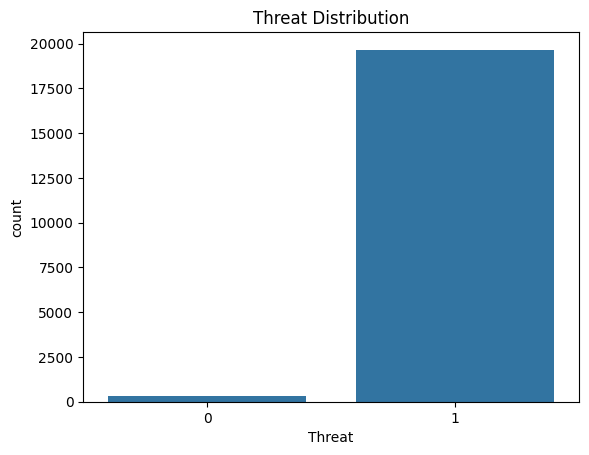

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x="Threat",
    data=df
)

plt.title("Threat Distribution")
plt.show()

Correlation Heatmap

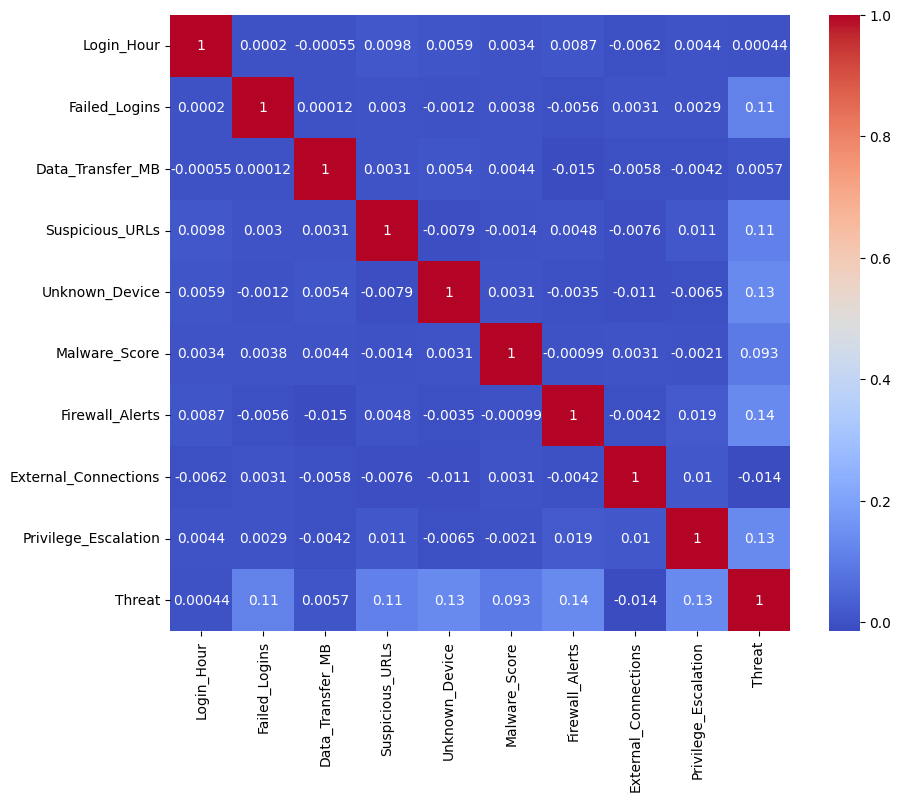

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Data Preprocessing

Feature Selection

In [ ]:
X = df.drop("Threat", axis=1)

y = df["Threat"]

Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Deep Learning Model

Build Neural Network

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(
    64,
    activation="relu",
    input_shape=(X_train.shape[1],)
))

model.add(Dropout(0.3))

model.add(Dense(
    32,
    activation="relu"
))

model.add(Dropout(0.3))

model.add(Dense(
    16,
    activation="relu"
))

model.add(Dense(
    1,
    activation="sigmoid"
))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

Compile Model

In [ ]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

Train Model

In [ ]:
history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=20,

    batch_size=64

)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9660 - loss: 0.1428 - val_accuracy: 0.9803 - val_loss: 0.0492
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9839 - loss: 0.0365 - val_accuracy: 0.9809 - val_loss: 0.0283
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9874 - loss: 0.0281 - val_accuracy: 0.9891 - val_loss: 0.0227
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9898 - loss: 0.0238 - val_accuracy: 0.9916 - val_loss: 0.0189
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9919 - loss: 0.0202 - val_accuracy: 0.9953 - val_loss: 0.0161
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9916 - loss: 0.0198 - val_accuracy: 0.9937 - val_loss: 0.0163
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9931 - loss: 0.0182 - val_accuracy: 0.9947 - val_loss: 0.0131
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9934 - loss: 0.0164 - val_accuracy: 0.

Performance Evaluation

Model Accuracy

In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9962 - loss: 0.0108
Accuracy: 0.9962499737739563


Generate Predictions

In [ ]:
predictions = model.predict(X_test)

predictions = (predictions > 0.5).astype(int)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(

    classification_report(
        y_test,
        predictions
    )

)

              precision    recall  f1-score   support

           0       0.98      0.82      0.89        77
           1       1.00      1.00      1.00      3923

    accuracy                           1.00      4000
   macro avg       0.99      0.91      0.95      4000
weighted avg       1.00      1.00      1.00      4000



Confusion Matrix

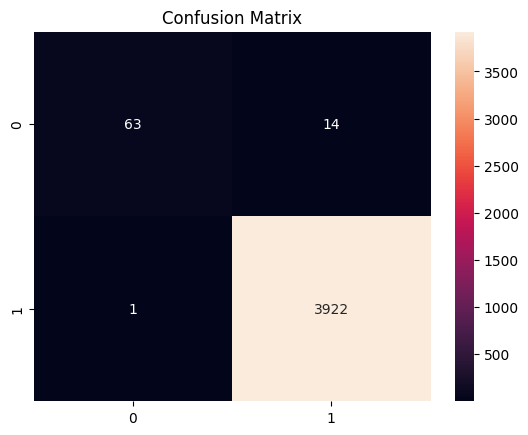

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.show()

Threat Prediction System

Test New Activity

In [ ]:
new_activity = pd.DataFrame({

    "Login_Hour":[2],

    "Failed_Logins":[12],

    "Data_Transfer_MB":[4500],

    "Suspicious_URLs":[15],

    "Unknown_Device":[1],

    "Malware_Score":[85],

    "Firewall_Alerts":[10],

    "External_Connections":[35],

    "Privilege_Escalation":[1]

})

Apply Scaling

In [ ]:
new_activity = scaler.transform(
    new_activity
)

Predict Threat

In [ ]:
prediction = model.predict(
    new_activity
)

if prediction[0][0] > 0.5:

    print("Threat Detected")

else:

    print("✓ Normal Activity")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
Threat Detected


Risk Scoring System

In [ ]:
risk_probability = prediction[0][0]

print(
    "Threat Probability:",
    round(
        risk_probability*100,
        2
    ),
    "%"
)

Threat Probability: 100.0 %


Training Visualizations

Accuracy Curve

Text(0.5, 1.0, 'Model Accuracy')

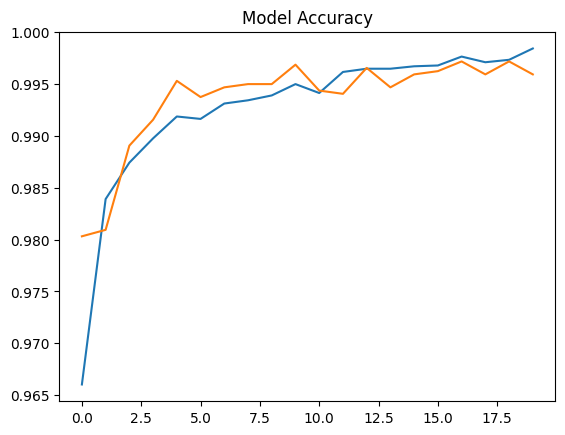

In [ ]:
plt.plot(
    history.history["accuracy"]
)

plt.plot(
    history.history["val_accuracy"]
)

plt.title(
    "Model Accuracy"
)

Loss Curve

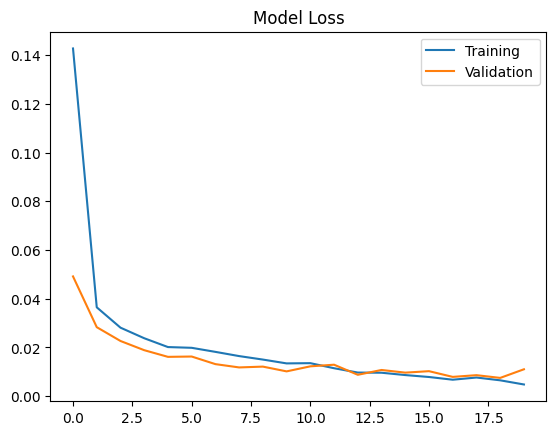

In [ ]:
plt.plot(
    history.history["loss"]
)

plt.plot(
    history.history["val_loss"]
)

plt.title(
    "Model Loss"
)

plt.legend(
    ["Training","Validation"]
)

plt.show()

Export Result

In [ ]:
results = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": predictions.flatten()

})

results.to_csv(

    "deep_learning_threat_detection_results.csv",

    index=False

)

print(
    "Results Exported Successfully"
)

Results Exported Successfully
